## 1. Project setup and paths

In [1]:
#import matplotlib
#matplotlib.use('Agg')  # headless (no display) backend
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os

# Set paths
TABLE_S5_PATH = '../data/supplementary_tables/1-s2.0-S0092867412012342-mmc5.xls'
PROCESSED_DATA_PATH = '../data/processed/table_s5_cleaned.csv'
FIGURE_PATH = '../results/figures/03_clip_vs_ribosome_scatter.png'
TABLE_A_PATH = '../results/tables/03_direct_candidates_threshold_A.csv'
TABLE_B_PATH = '../results/tables/03_direct_candidates_threshold_B.csv'


## 2. Load Table S5

In [2]:
# Load Table S5
# skipping the first row because it contains a long text description
df = pd.read_excel(TABLE_S5_PATH, sheet_name=0, skiprows=1)
df.head()


,Accession,Gene Symbol,CLIP-seq p-value,CLIP-seq FDR,RNA-seq reads (for normalization),CLIP-seq reads (35L33G),"CLIP-seq enrichment (35L33G, log2)",CLIP-seq reads (2J3),"CLIP-seq enrichment (2J3, log2)",CLIP-seq reads (polyclonal),...,Ribosome occupancy change (log2),RPF reads (siLuc),RNA-seq short tag alignment reads (siLuc),RPF reads (siLin28a),RNA-seq short tag alignment reads (siLin28a),"RNA-seq reads (untreated, RPKM)","RNA-seq reads (siLuc, RPKM)","RNA-seq reads (siLin28a, RPKM)",RNA-seq mRNA change upon Lin28a KD (log2),Description
0,NM_144953,1700019D03Rik,0.281842,0.979502,279.0,332.0,0.250095,318.0,0.188130,239.0,...,1.264492,4.068613,60.336753,9.774542,43.247437,42.025601,27.961188,42.025601,-0.586121,UPF0733 protein C2orf88 homolog
1,NM_023065,Ifi30,0.367368,1.000000,392.0,329.0,-0.252063,365.0,-0.102686,413.0,...,0.561661,113.808914,43.155298,167.978265,23.261108,41.549619,25.761339,41.549619,-0.687506,gamma-interferon-inducible lysosomal thiol red...
2,NM_001039368,Polr2k,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.050795,235.875985,84.486353,227.715734,31.158336,5.402914,4.709134,5.402914,-0.194419,"DNA-directed RNA polymerases I, II, and III su..."
3,NM_173734,Tmem87a,0.001109,0.045502,479.0,1807.0,1.913288,1929.0,2.007495,1935.0,...,0.898551,60.458230,21.666446,112.705810,15.452414,19.835616,14.155786,19.835616,-0.483801,transmembrane protein 87A isoform 1
4,NM_010685,Lamp2,0.001147,0.046476,666.0,2323.0,1.800851,2742.0,2.039996,2796.0,...,1.163965,113.782459,22.512578,254.955136,19.355307,22.871526,19.936939,22.871526,-0.197185,lysosome-associated membrane glycoprotein 2 is...


## 3. Inspect columns and missing values

In [3]:
print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\nAll column names (index + repr):')
for i, col in enumerate(df.columns):
    print(f'  {i}: {repr(col)}')

print('\nMissing values count:')
print(df.isnull().sum())


Shape: (16465, 22)
Rows: 16465, Columns: 22

All column names (index + repr):
  0: 'Accession'
  1: 'Gene Symbol'
  2: 'CLIP-seq p-value'
  3: 'CLIP-seq FDR'
  4: 'RNA-seq reads (for normalization)'
  5: 'CLIP-seq reads (35L33G)'
  6: 'CLIP-seq enrichment (35L33G, log2)'
  7: 'CLIP-seq reads (2J3)'
  8: 'CLIP-seq enrichment (2J3, log2)'
  9: 'CLIP-seq reads (polyclonal)'
  10: 'CLIP-seq enrichment (polyclonal, log2)'
  11: 'Ribosome density change (log2)'
  12: 'Ribosome occupancy change (log2)'
  13: 'RPF  reads (siLuc)'
  14: 'RNA-seq short tag alignment reads (siLuc)'
  15: 'RPF  reads (siLin28a)'
  16: 'RNA-seq short tag alignment reads (siLin28a)'
  17: 'RNA-seq reads (untreated, RPKM)'
  18: 'RNA-seq reads (siLuc, RPKM)'
  19: 'RNA-seq reads (siLin28a, RPKM)'
  20: 'RNA-seq mRNA change upon Lin28a KD (log2)'
  21: 'Description'

Missing values count:
Accession                                           0
Gene Symbol                                         0
CLIP-seq p-value       

## 4. Identify key columns

In [4]:
# Key column mapping (verified from actual df.columns above)
# Transcript accession: 'Accession'
# Gene symbol: 'Gene Symbol'
# CLIP-seq p-value: 'CLIP-seq p-value'
# CLIP-seq FDR: 'CLIP-seq FDR'
# CLIP enrichment columns:
#   'CLIP-seq enrichment (35L33G, log2)'
#   'CLIP-seq enrichment (2J3, log2)'
#   'CLIP-seq enrichment (polyclonal, log2)'
# Ribosome density change: 'Ribosome density change (log2)'
# RNA-seq mRNA change: 'RNA-seq mRNA change upon Lin28a KD (log2)'
# Gene description: 'Description'

# Save the cleaned table without biological thresholds
df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f'Saved cleaned table to {PROCESSED_DATA_PATH}')
print('NOTE: Full column-level data dictionary is in notes/table_s5_data_dictionary.md')


Saved cleaned table to ../data/processed/table_s5_cleaned.csv
NOTE: Full column-level data dictionary is in notes/table_s5_data_dictionary.md


## 5. Calculate mean CLIP enrichment

In [5]:
# Auto-detect CLIP enrichment columns: must contain 'CLIP-seq enrichment', 'log2',
# and one of the three antibody identifiers
clip_enrichment_cols = [
    c for c in df.columns
    if ('CLIP-seq enrichment' in c)
    and ('log2' in c)
    and any(rep in c for rep in ['35L33G', '2J3', 'polyclonal'])
]

print('Detected CLIP enrichment columns:')
for c in clip_enrichment_cols:
    print(f'  {repr(c)}')

if len(clip_enrichment_cols) != 3:
    raise ValueError(
        f'Expected 3 CLIP enrichment columns, found {len(clip_enrichment_cols)}: {clip_enrichment_cols}'
    )

for col in clip_enrichment_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['mean_CLIP_enrichment'] = df[clip_enrichment_cols].mean(axis=1)
print(f'\nmean_CLIP_enrichment computed for {df["mean_CLIP_enrichment"].notna().sum()} transcripts')
print(df[['Gene Symbol', 'mean_CLIP_enrichment']].dropna().head(10))


Detected CLIP enrichment columns:
  'CLIP-seq enrichment (35L33G, log2)'
  'CLIP-seq enrichment (2J3, log2)'
  'CLIP-seq enrichment (polyclonal, log2)'

mean_CLIP_enrichment computed for 10716 transcripts
      Gene Symbol  mean_CLIP_enrichment
0   1700019D03Rik              0.071944
1           Ifi30             -0.093216
3         Tmem87a              1.977585
4           Lamp2              1.969656
5          Leprot              0.668500
6            Tmx1              2.756122
7         Anapc16             -0.302562
8           Tmub2             -1.095346
9          Tm9sf3              2.053333
10           Stc2              1.628729


## 6. Inspect distributions

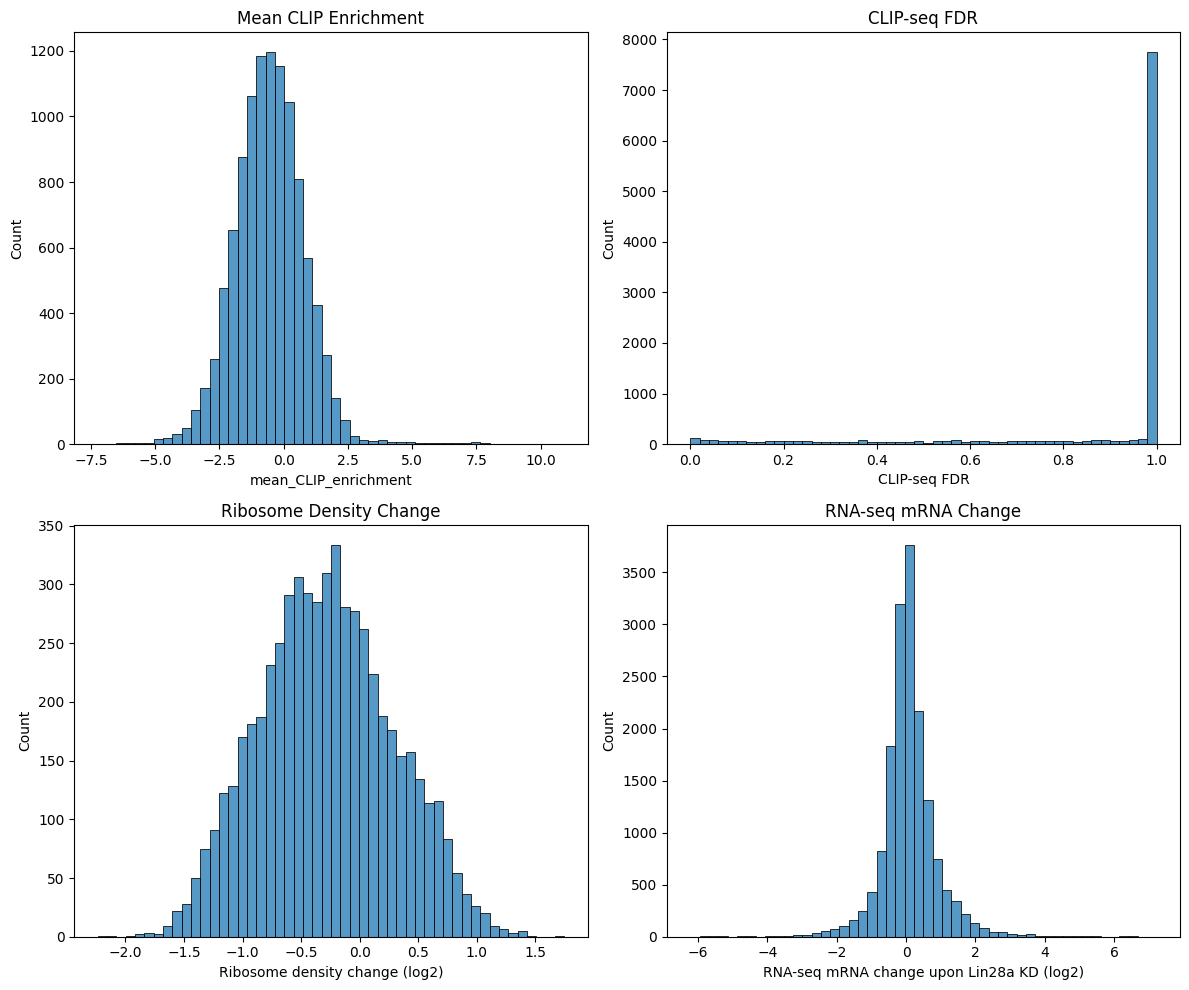

In [6]:
# Set column names explicitly based on the validated mappings
ribo_col = 'Ribosome density change (log2)'
rna_col = 'RNA-seq mRNA change upon Lin28a KD (log2)'

df[ribo_col] = pd.to_numeric(df[ribo_col], errors='coerce')
df[rna_col] = pd.to_numeric(df[rna_col], errors='coerce')
df['CLIP-seq FDR'] = pd.to_numeric(df['CLIP-seq FDR'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['mean_CLIP_enrichment'].dropna(), bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Mean CLIP Enrichment')

sns.histplot(df['CLIP-seq FDR'].dropna(), bins=50, ax=axes[0, 1])
axes[0, 1].set_title('CLIP-seq FDR')

sns.histplot(df[ribo_col].dropna(), bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Ribosome Density Change')

sns.histplot(df[rna_col].dropna(), bins=50, ax=axes[1, 1])
axes[1, 1].set_title('RNA-seq mRNA Change')
plt.tight_layout()
plt.show()


## 7. Compare threshold set A and B

In [7]:
# Threshold set A:
# - CLIP-seq FDR < 0.05
# - mean CLIP enrichment > 1
# - ribosome density change > 0
# - abs(mRNA change) < 0.5
cond_A = (df['CLIP-seq FDR'] < 0.05) & \
         (df['mean_CLIP_enrichment'] > 1) & \
         (df[ribo_col] > 0) & \
         (df[rna_col].abs() < 0.5)

# Threshold set B:
# - CLIP-seq FDR < 0.05
# - mean CLIP enrichment in top 20%
# - ribosome density change > 0.3
# - abs(mRNA change) < 0.5
top20_clip = df['mean_CLIP_enrichment'].quantile(0.8)
cond_B = (df['CLIP-seq FDR'] < 0.05) & \
         (df['mean_CLIP_enrichment'] > top20_clip) & \
         (df[ribo_col] > 0.3) & \
         (df[rna_col].abs() < 0.5)

df_A = df[cond_A].copy()
df_B = df[cond_B].copy()

print(f"Threshold Set A selected {len(df_A)} transcripts, {df_A['Gene Symbol'].nunique()} unique genes.")
print(f"Threshold Set B selected {len(df_B)} transcripts, {df_B['Gene Symbol'].nunique()} unique genes.")

# Top 20 for A
print("\nTop 20 candidates (Threshold A) by mean CLIP enrichment and ribosome density change:")
print(df_A.sort_values(by=['mean_CLIP_enrichment', ribo_col], ascending=[False, False])[['Gene Symbol', 'mean_CLIP_enrichment', ribo_col]].head(20))

# Top 20 for B
print("\nTop 20 candidates (Threshold B) by mean CLIP enrichment and ribosome density change:")
print(df_B.sort_values(by=['mean_CLIP_enrichment', ribo_col], ascending=[False, False])[['Gene Symbol', 'mean_CLIP_enrichment', ribo_col]].head(20))


Threshold Set A selected 56 transcripts, 56 unique genes.
Threshold Set B selected 48 transcripts, 48 unique genes.

Top 20 candidates (Threshold A) by mean CLIP enrichment and ribosome density change:
     Gene Symbol  mean_CLIP_enrichment  Ribosome density change (log2)
913       Pgrmc1              4.031423                        0.314690
396         Ktn1              2.913330                        0.605197
109        Pvrl3              2.882220                        0.867100
6           Tmx1              2.756122                        1.373095
47       Slc30a1              2.724813                        1.017830
76       Dnajb11              2.706131                        0.938012
283         Canx              2.611463                        0.680821
123        Yipf4              2.565632                        0.844765
601       Ergic2              2.525520                        0.476612
68         Mfsd1              2.511597                        0.961316
634      Atp6ap1 

## 8. Generate main scatter plot

In [8]:
fdr_col = 'CLIP-seq FDR'

# 1. Plot dataframe: only rows with ALL 4 columns non-NA
df_plot = df.dropna(subset=['mean_CLIP_enrichment', ribo_col, rna_col, fdr_col]).copy()
print(f'Plot base (all 4 non-NA): {len(df_plot)} rows')

# 2. Threshold conditions on df_plot
top20_clip = df['mean_CLIP_enrichment'].quantile(0.8)
cond_plot_A = (
    (df_plot[fdr_col] < 0.05) &
    (df_plot['mean_CLIP_enrichment'] > 1) &
    (df_plot[ribo_col] > 0) &
    (df_plot[rna_col].abs() < 0.5)
)
cond_plot_B = (
    (df_plot[fdr_col] < 0.05) &
    (df_plot['mean_CLIP_enrichment'] > top20_clip) &
    (df_plot[ribo_col] > 0.3) &
    (df_plot[rna_col].abs() < 0.5)
)

# 3. Four candidate groups
def assign_group(a, b):
    if a and b:   return 'A and B overlap'
    elif a:       return 'Threshold A only'
    elif b:       return 'Threshold B only'
    else:         return 'Not candidate'

df_plot['group'] = [assign_group(a, b) for a, b in zip(cond_plot_A, cond_plot_B)]

group_order = ['Not candidate', 'Threshold A only', 'Threshold B only', 'A and B overlap']
print('\nGroup counts:')
for g in group_order:
    print(f'  {g}: {(df_plot["group"] == g).sum()}')

# 4. Plot
NEW_FIGURE_PATH = '../results/figures/03_clip_vs_ribosome_scatter_candidates.png'
fig, ax = plt.subplots(figsize=(10, 8))

bg = df_plot[df_plot['group'] == 'Not candidate']
ax.scatter(bg['mean_CLIP_enrichment'], bg[ribo_col],
           c='#AAAAAA', alpha=0.20, s=6, linewidths=0,
           label=f'Not candidate (n={len(bg)})', rasterized=True)

cand_styles = {
    'Threshold A only': {'c': '#4393C3', 's': 50, 'zorder': 4},
    'Threshold B only': {'c': '#F4A261', 's': 50, 'zorder': 4},
    'A and B overlap':  {'c': '#E63946', 's': 70, 'zorder': 5},
}
for g, style in cand_styles.items():
    sub = df_plot[df_plot['group'] == g]
    if len(sub) == 0:
        continue
    ax.scatter(sub['mean_CLIP_enrichment'], sub[ribo_col],
               c=style['c'], edgecolors='black', linewidths=0.7,
               alpha=0.9, s=style['s'], zorder=style['zorder'],
               label=f'{g} (n={len(sub)})')

ax.axhline(0,          color='#555555', linewidth=0.7, linestyle='--')
ax.axvline(0,          color='#555555', linewidth=0.7, linestyle='--')
ax.axhline(0.3,        color='#F4A261', linewidth=0.6, linestyle=':', alpha=0.7)
ax.axvline(1,          color='#4393C3', linewidth=0.6, linestyle=':', alpha=0.7)
ax.axvline(top20_clip, color='#E63946', linewidth=0.6, linestyle=':', alpha=0.7)

ax.set_xlabel('Mean CLIP Enrichment (35L33G + 2J3 + polyclonal, log2)', fontsize=12)
ax.set_ylabel('Ribosome Density Change upon Lin28a KD (log2)', fontsize=12)
ax.set_title(
    'LIN28A CLIP Enrichment vs Ribosome Density Change\n'
    '(only rows with non-NA CLIP enrichment, ribosome change, mRNA change, and FDR)',
    fontsize=12
)
ax.legend(loc='upper left', framealpha=0.85, fontsize=10)
fig.tight_layout()
fig.savefig(NEW_FIGURE_PATH, dpi=300)
plt.close()
print(f'Saved: {NEW_FIGURE_PATH}')


Plot base (all 4 non-NA): 5649 rows

Group counts:
  Not candidate: 5593
  Threshold A only: 8
  Threshold B only: 0
  A and B overlap: 48
Saved: ../results/figures/03_clip_vs_ribosome_scatter_candidates.png


## 9. Save candidate tables

In [9]:
df_A.to_csv(TABLE_A_PATH, index=False)
df_B.to_csv(TABLE_B_PATH, index=False)
print("Saved candidate tables.")


Saved candidate tables.


## 10. Summary and next steps

In [10]:
# Write threshold summary to notes
top20_clip = df['mean_CLIP_enrichment'].quantile(0.8)

def top10_rows_md(df_top):
    rows = ''
    for _, r in df_top[['Gene Symbol', 'mean_CLIP_enrichment', ribo_col, rna_col]].head(10).iterrows():
        rows += f"| {r['Gene Symbol']} | {r['mean_CLIP_enrichment']:.3f} | {r[ribo_col]:.3f} | {r[rna_col]:.3f} |\n"
    return rows

summary = f"""
# 03 Threshold Summary

## Analysis: Direct LIN28A Translational Repression Candidates (Spec 03)

Mean CLIP enrichment = average of 3 CLIP enrichment columns:
- `CLIP-seq enrichment (35L33G, log2)`
- `CLIP-seq enrichment (2J3, log2)`
- `CLIP-seq enrichment (polyclonal, log2)`

## Threshold Set A

| Criterion | Column | Cutoff | Justification |
|---|---|---|---|
| CLIP binding | CLIP-seq FDR | < 0.05 | Standard FDR cutoff |
| CLIP enrichment | mean_CLIP_enrichment | > 1 (log2) | >2-fold enrichment |
| Translational repression | Ribosome density change (log2) | > 0 | Any increase upon KD |
| Translational specificity | RNA-seq mRNA change (log2) | |x| < 0.5 | Exclude mRNA abundance changes |

**Selected: {len(df_A)} transcripts, {df_A['Gene Symbol'].nunique()} unique genes**

## Threshold Set B (more stringent)

| Criterion | Column | Cutoff | Justification |
|---|---|---|---|
| CLIP binding | CLIP-seq FDR | < 0.05 | Standard FDR cutoff |
| CLIP enrichment | mean_CLIP_enrichment | > top 20% (>{top20_clip:.3f}) | Top quintile |
| Translational repression | Ribosome density change (log2) | > 0.3 | More than minimal change |
| Translational specificity | RNA-seq mRNA change (log2) | |x| < 0.5 | Exclude mRNA abundance changes |

**Selected: {len(df_B)} transcripts, {df_B['Gene Symbol'].nunique()} unique genes**

## Comparison

| | Threshold A | Threshold B |
|---|---|---|
| Transcripts | {len(df_A)} | {len(df_B)} |
| Unique genes | {df_A['Gene Symbol'].nunique()} | {df_B['Gene Symbol'].nunique()} |
| CLIP cutoff | > 1 | top 20% (>{top20_clip:.3f}) |
| Ribosome density cutoff | > 0 | > 0.3 |
"""

with open('../notes/03_threshold_summary.md', 'w') as f:
    f.write(summary.lstrip())
print('Saved 03_threshold_summary.md')
print(f'Set A: {len(df_A)} transcripts, {df_A["Gene Symbol"].nunique()} genes')
print(f'Set B: {len(df_B)} transcripts, {df_B["Gene Symbol"].nunique()} genes')


Saved 03_threshold_summary.md
Set A: 56 transcripts, 56 genes
Set B: 48 transcripts, 48 genes
